# 石墨烯与 MoS₂：转动求和规则

同一个 FC2 拟合，在两种物理后处理下会给出不同的声子谱：

- **ASR（声学求和规则）**：在指定数值容差内修复平移不变性，使 $\Gamma$ 点的三个声学模趋近于零；
- **ASR + Born–Huang + Huang**：先修复 ASR，再联合处理旋转一次矩和零应力二次矩，
  旋转修正保留已有声学残差。Born–Huang 的齐次形式要求原子力平衡，Huang 还要求零应力。

两个材料各有一条训练集：石墨烯用 $7\times7\times1$ 超胞，MoS₂ 单层用
$8\times8\times1$ 超胞，截断都是 8 Å、二体 cluster space。两个拟合互相独立，
最后对每种材料并排画出两条声子谱。

运行环境见[教程总览](index.md)；本 notebook 只依赖 `tutorial` 依赖组。

In [1]:
import warnings
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.calculators.singlepoint import SinglePointCalculator
from ase.io import iread, read
from phonopy.structure.cells import PrimitiveMatrixAutoDefaultWarning

import mlfcs
from mlfcs import ClusterMap, ClusterSpace, FitSystem

# phonopy v4 对 primitive_matrix="auto" 的默认值变更提示与本教程无关。
warnings.filterwarnings("ignore", category=PrimitiveMatrixAutoDefaultWarning)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

DATA = Path("data") / "rotational-sum-rules"
SOLVER_RTOL = 1e-8
print(f"mlfcs {mlfcs.__version__}")

mlfcs 4.6.0


## 拟合与投影

石墨烯的训练文件只存位移与力，需要把位移叠加到理想超胞上、再用
`SinglePointCalculator` 挂回存储的力；MoS₂ 的训练帧本身就是带力的 ASE 结构，
可以通过 `ForceDataset` 交给 `FitSystem`。两种投影的区别只在拟合之后：

- `asr`：`enforce_asr()` 只做平移不变性投影；
- `rotation`：先 `enforce_asr()`，再对结果 `enforce_rotation(born_huang=True, huang=True)`
  做一次联合的 Born–Huang 旋转与 Huang 平衡投影。

ASR 使用无矩阵算子与浮点 LSMR；旋转使用实际原子间距构造约束并进行 SVD。
`rtol` 是 ASR 的相对残差容差，`rank_rtol` 是旋转的相对奇异值截断比例；
默认截断来自实际几何误差，被截断方向可能保留残差。两步最小化的都是物理分量参数的欧氏改变量，
并非全部展开张量元素的改变量。整数核只用于更早的轨道不变基构造。

In [2]:
from mlfcs.dataset import ForceDataset
MATERIALS = {
    "graphene": {"supercell_matrix": ((7, 0, 0), (0, 7, 0), (0, 0, 1))},
    "mos2": {"supercell_matrix": ((8, 0, 0), (0, 8, 0), (0, 0, 1))},
}


def training_structures(supercell_atoms, frames):
    """Reconstruct force-bearing supercell snapshots from stored graphene displacements."""
    for source in frames:
        atoms = supercell_atoms.copy()
        atoms.positions += source.arrays["displacements"]
        forces = source.calc.get_property("forces", source, allow_calculation=False)
        atoms.calc = SinglePointCalculator(atoms, forces=forces)
        yield atoms


def fit_fc2(material, projection):
    """Fit FC2 for one material and return the selected projection with diagnostics."""
    spec = MATERIALS[material]
    directory = DATA / material
    primitive = read(directory / "primitive.vasp")
    supercell_atoms = read(directory / "supercell.vasp")

    space = ClusterSpace(
        primitive, cutoffs={2: 8.0}, max_body_orders={2: 2}, symprec=1e-5
    )
    mapping = ClusterMap(space, supercell_atoms, supercell_matrix=spec["supercell_matrix"])
    frames = iread(directory / "training.extxyz", index=":")
    if material == "graphene":
        structures = training_structures(supercell_atoms, frames)
    else:
        structures = frames
    system = FitSystem(ForceDataset(mapping, structures))
    raw = system.solve(rtol=SOLVER_RTOL, maxiter=10_000)

    if projection == "asr":
        result = raw.enforce_asr()
        label = "ASR"
    else:
        result = raw.enforce_asr().force_constants.enforce_rotation(
            born_huang=True, huang=True
        )
        label = "ASR + Born-Huang + Huang"
    fitted = result.force_constants

    summary = {
        "material": material,
        "projection": label,
        "mapping": mapping,
        "model": fitted,
        "frames": system.n_structures,
        "equations": system.n_equations,
        "parameters": system.n_parameters,
        "relative_before": system.relative_error(raw.parameters()),
        "relative_after": system.relative_error(fitted.parameters()),
    }
    print(
        f"{material} [{label}]: {summary['frames']} frames, "
        f"{summary['parameters']} parameters, "
        f"relative force error {summary['relative_before']:.6%} -> "
        f"{summary['relative_after']:.6%}"
    )
    return summary

跑全 $2\times2$ 组合并保留结果，声子谱一节直接复用：

- 石墨烯两种投影的相对力误差几乎不变（转动分量本来就小）；
- MoS₂ 的转动投影按设计保留约 10% 的训练相对误差——它优先满足转动条件，
  不追求把拟合残差压到零。

In [3]:
RESULTS = {}
for material in MATERIALS:
    for projection in ("asr", "rotation"):
        RESULTS[(material, projection)] = fit_fc2(material, projection)

2026-10-07 16:54:50 INFO mlfcs.cluster_space.construction: Cluster-space construction started: primitive_atoms=2 orders=(2,) symprec=1e-05


2026-10-07 16:54:50 INFO mlfcs.cluster_space.construction: Primitive symmetry ready: operations=24 symbol=P6/mmm


2026-10-07 16:54:50 INFO mlfcs.cluster_space.construction: Order construction started: order=2 cutoff_angstrom=8 max_body_order=2


2026-10-07 16:54:50 INFO mlfcs.cluster_space.construction: Candidates ready: order=2 candidates=158


2026-10-07 16:54:50 INFO mlfcs.cluster_space.construction: Order complete: order=2 orbits=15 parameters=54 elapsed_s=0.20


...

2026-10-07 16:54:51 INFO mlfcs.force_constants.asr: ASR order complete: order=2 equations=27 iterations=4 relative_before=0.00017633 relative_after=2.17123e-17 correction_norm=0.0330701


2026-10-07 16:54:51 INFO mlfcs.force_constants.asr: ASR projection complete: orders=(2,) elapsed_s=0.00


2026-10-07 16:54:51 INFO mlfcs.force_constants.rotation: Rotation projection started: born_huang=True huang=True rank_rtol=automatic


2026-10-07 16:54:51 INFO mlfcs.force_constants.rotation: Rotation projection complete: retained_rank=2 rank_cutoff=7.99682e-05 relative_before=4.79574e-05 relative_after=7.15865e-09 correction_norm=0.0188117 acoustic_before=2.75335e-14 acoustic_after=2.75335e-14 elapsed_s=0.12


mos2 [ASR + Born-Huang + Huang]: 5 frames, 84 parameters, relative force error 10.052448% -> 10.054869%


In [4]:
for material in MATERIALS:
    print(f"--- {material} ---")
    for projection in ("asr", "rotation"):
        summary = RESULTS[(material, projection)]
        print(
            f"  {summary['projection']:<24} relative error "
            f"{summary['relative_before']:.6%} -> {summary['relative_after']:.6%}"
        )

--- graphene ---
  ASR                      relative error 1.050475% -> 1.050603%
  ASR + Born-Huang + Huang relative error 1.050475% -> 1.051257%
--- mos2 ---
  ASR                      relative error 10.052448% -> 10.054122%
  ASR + Born-Huang + Huang relative error 10.052448% -> 10.054869%


## 声子谱对比

使用 ASE BandPath 明确指定二维六角路径 Γ–M–K–Γ，再交给
`Harmonic.run_band_path()`。本库仍按三维周期体系计算，但这里指定的所有 q 点都在平面内。
不需要将 FC2 导出、读回才能画图。

2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=2


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=158 elapsed_s=0.00


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=300 modes_per_q=6 imaginary_modes=46 range=[-0.48009568, 47.726379] THz elapsed=0.01 s


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=2


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=158 elapsed_s=0.00


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=300 modes_per_q=6 imaginary_modes=4 range=[-5.8818422e-07, 47.726379] THz elapsed=0.00 s


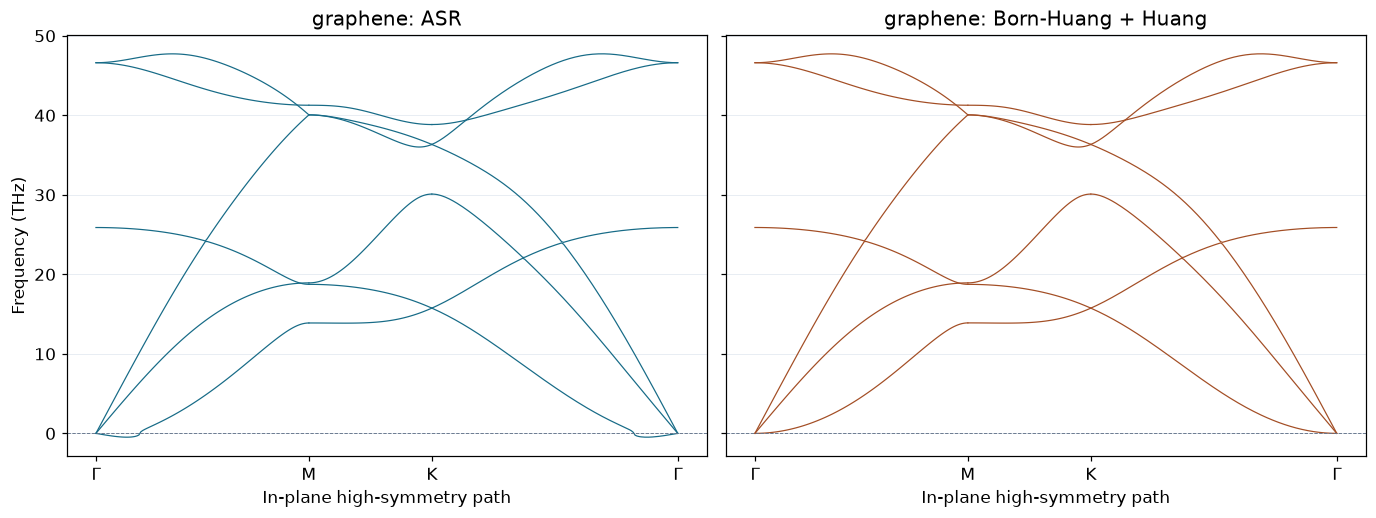

2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=3


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=179 elapsed_s=0.01


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=300 modes_per_q=9 imaginary_modes=44 range=[-0.35100076, 14.169096] THz elapsed=0.00 s


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic preparation started: primitive_atoms=3


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic preparation complete: terms=179 elapsed_s=0.01


2026-10-07 16:54:51 INFO mlfcs.phonon.harmonic: Harmonic frequencies: qpoints=300 modes_per_q=9 imaginary_modes=2 range=[-1.7604407e-08, 14.171676] THz elapsed=0.00 s


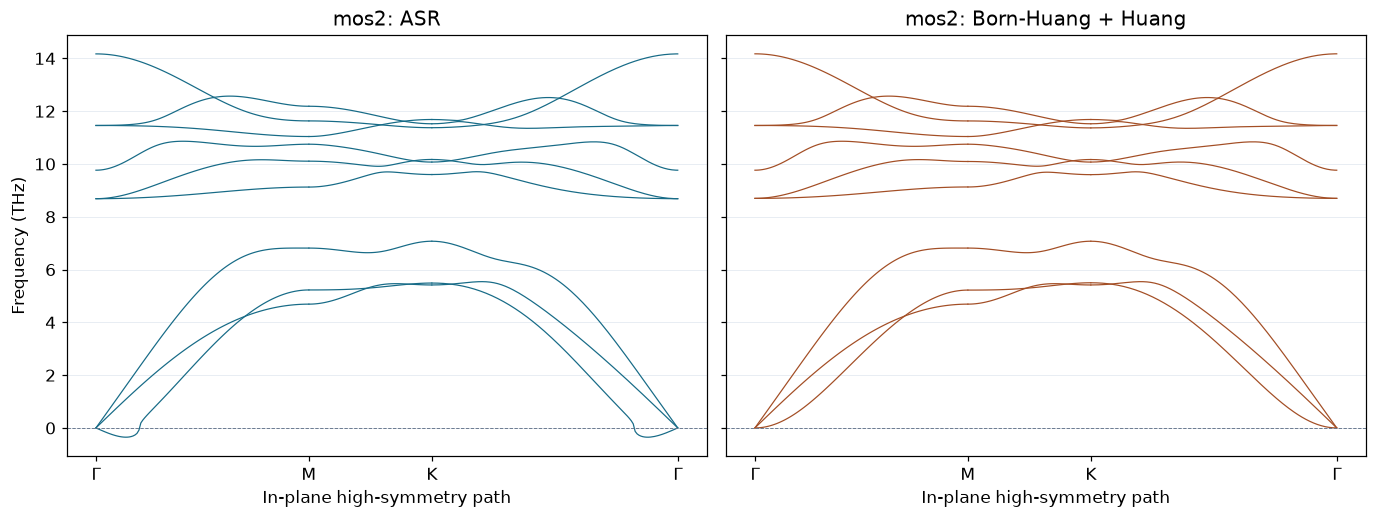

In [5]:
from mlfcs.phonon import Harmonic


def plot_material(material):
    """Compare acoustic and rotational projections along the same in-plane path."""
    asr_model = RESULTS[(material, "asr")]["model"]
    cell = asr_model.cluster_space.primitive_atoms.cell
    path = cell.bandpath(
        "GMKG",
        special_points={"G": (0, 0, 0), "M": (0.5, 0, 0), "K": (1 / 3, 1 / 3, 0)},
        npoints=300,
    )
    panels = [
        (asr_model, "ASR", "#176b87"),
        (RESULTS[(material, "rotation")]["model"], "Born-Huang + Huang", "#a34e25"),
    ]
    figure, axes = plt.subplots(1, 2, figsize=(12.4, 4.6), sharey=True, constrained_layout=True)
    for axis, (model, title, color) in zip(axes, panels):
        bands = Harmonic(model).run_band_path(path)
        for segment in bands.segments:
            axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color=color, linewidth=0.8)
        axis.set_title(f"{material}: {title}")
        axis.set_xticks(bands.tick_positions, bands.tick_labels)
        axis.axhline(0.0, color="#64748b", linewidth=0.6, linestyle="--")
        axis.grid(axis="y", color="#e2e8f0", linewidth=0.5)
        axis.set_xlabel("In-plane high-symmetry path")
    axes[0].set_ylabel("Frequency (THz)")
    plt.show()


plot_material("graphene")
plot_material("mos2")

## 结果解读

- **石墨烯**：二体模型 + 高对称结构下，拟合残差中几乎没有可分辨的转动分量，
  两种投影的色散在图上基本重合；ASR 已经把声学模钉在零频。
- **MoS₂**：转动投影保留了约 10% 的训练相对误差。这是联合投影的预期行为——
  它优先满足 Born–Huang 与 Huang 条件，训练残差只降到几何误差允许的水平，
  Born–Huang/Huang 残差小但不严格为零。这不构成对严格转动不变性的声明。

`enforce_rotation` 返回的 `RotationResult` 携带逐条件的残差与奇异值信息，
需要定量结论时直接检查 `summary` 中模型的投影报告即可。

## 小结

- `enforce_asr` 与 `enforce_rotation` 都是 `ForceConstants` 上的纯后处理，
  不触碰 cluster space 与拟合系统；
- 转动条件的引入会以训练残差为代价换取物理约束，取舍幅度可以从
  `relative_before/after` 直接读出；
- `Harmonic.run_band_path` 直接消费参数模型；需要交给外部程序时再调用 `model.write`。